# GPU V1 — One Thread per Output Pixel

GPU V1 assigns one CUDA thread to each output pixel.

Each thread:

1. identifies its reference patch;
2. scans candidate centers in the search window;
3. computes patch mean squared distance;
4. converts distance to a similarity weight;
5. accumulates candidate center pixels;
6. writes one denoised output pixel.

This version accesses all image data through global memory.
It provides the correctness and performance baseline for GPU V2.

In [1]:
from pathlib import Path
import sys


def find_project_root() -> Path:
    current = Path.cwd().resolve()

    for path in [current, *current.parents]:
        if (
            (path / "src").exists()
            and (path / "kernels").exists()
            and (path / "pyproject.toml").exists()
        ):
            return path

    raise FileNotFoundError(
        "Cannot locate project root."
    )


PROJECT_ROOT = find_project_root()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(
        0,
        str(PROJECT_ROOT),
    )

print("Project root:", PROJECT_ROOT)

Project root: E:\Lap trinh song song ud\gpu_dense_vector_retrieval


In [2]:
import cupy as cp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.nlm.benchmark import (
    benchmark_cpu_function,
    benchmark_cuda_kernel,
    benchmark_gpu_end_to_end,
)

from src.nlm.config import NLMConfig
from src.nlm.cpu import nlm_cpu_naive

from src.nlm.gpu_v1 import (
    create_gpu_v1_kernel_launcher,
    nlm_gpu_v1,
)

from src.nlm.image_utils import (
    add_gaussian_noise,
    create_camera_test_image,
)

from src.nlm.metrics import (
    compare_outputs,
    evaluate_denoising,
)

In [3]:
import cupy as cp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.nlm.benchmark import (
    benchmark_cpu_function,
    benchmark_cuda_kernel,
    benchmark_gpu_end_to_end,
)

from src.nlm.config import NLMConfig
from src.nlm.cpu import nlm_cpu_naive

from src.nlm.gpu_v1 import (
    create_gpu_v1_kernel_launcher,
    nlm_gpu_v1,
)

from src.nlm.image_utils import (
    add_gaussian_noise,
    create_camera_test_image,
)

from src.nlm.metrics import (
    compare_outputs,
    evaluate_denoising,
)

In [4]:
config = NLMConfig(
    image_size=64,
    noise_sigma=0.08,
    patch_size=3,
    search_window_size=7,
    h=0.12,
    random_seed=42,
    block_size_x=16,
    block_size_y=16,
)

config.validate()

print(config)

NLMConfig(image_size=64, noise_sigma=0.08, patch_size=3, search_window_size=7, h=0.12, random_seed=42, block_size_x=16, block_size_y=16)


In [5]:
clean_image = create_camera_test_image(
    image_size=config.image_size
)

noisy_image = add_gaussian_noise(
    image=clean_image,
    sigma=config.noise_sigma,
    seed=config.random_seed,
)

print(
    clean_image.shape,
    clean_image.dtype,
)

(64, 64) float32


In [6]:
clean_image = create_camera_test_image(
    image_size=config.image_size
)

noisy_image = add_gaussian_noise(
    image=clean_image,
    sigma=config.noise_sigma,
    seed=config.random_seed,
)

print(
    clean_image.shape,
    clean_image.dtype,
)

(64, 64) float32


In [7]:
denoised_cpu = nlm_cpu_naive(
    image=noisy_image,
    patch_size=config.patch_size,
    search_window_size=(
        config.search_window_size
    ),
    h=config.h,
)

In [9]:
_ = nlm_gpu_v1(
    image=noisy_image,
    patch_size=config.patch_size,
    search_window_size=(
        config.search_window_size
    ),
    h=config.h,
    block_size=config.block_size,
)

denoised_gpu_v1 = nlm_gpu_v1(
    image=noisy_image,
    patch_size=config.patch_size,
    search_window_size=(
        config.search_window_size
    ),
    h=config.h,
    block_size=config.block_size,
)

In [10]:
gpu_v1_correctness = compare_outputs(
    reference=denoised_cpu,
    candidate=denoised_gpu_v1,
    atol=1e-5,
    rtol=1e-5,
)

gpu_v1_correctness

{'max_absolute_error': 5.364418029785156e-07,
 'mean_absolute_error': 6.034497346263379e-08,
 'rmse': 8.93803604841094e-08,
 'allclose': True}

In [11]:
_ = nlm_gpu_v1(
    image=noisy_image,
    patch_size=config.patch_size,
    search_window_size=(
        config.search_window_size
    ),
    h=config.h,
    block_size=config.block_size,
)

denoised_gpu_v1 = nlm_gpu_v1(
    image=noisy_image,
    patch_size=config.patch_size,
    search_window_size=(
        config.search_window_size
    ),
    h=config.h,
    block_size=config.block_size,
)

In [13]:
cpu_quality = evaluate_denoising(
    clean=clean_image,
    noisy=noisy_image,
    denoised=denoised_cpu,
)

gpu_v1_quality = evaluate_denoising(
    clean=clean_image,
    noisy=noisy_image,
    denoised=denoised_gpu_v1,
)

quality_table = pd.DataFrame(
    [
        {
            "Implementation": "CPU reference",
            **cpu_quality,
        },
        {
            "Implementation": "GPU V1",
            **gpu_v1_quality,
        },
    ]
)

display(quality_table)

,Implementation,noisy_psnr,denoised_psnr,denoised_ssim,psnr_improvement
0,CPU reference,22.218338,29.53202,0.838319,7.313682
1,GPU V1,22.218338,29.53202,0.838319,7.313682


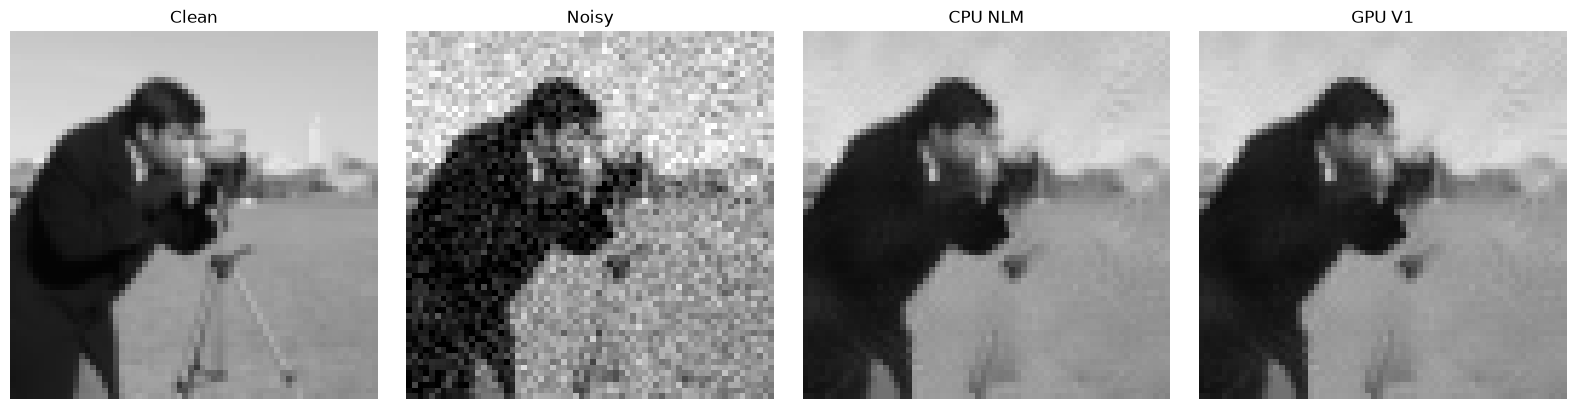

In [12]:
plt.figure(figsize=(16, 4))

images = [
    ("Clean", clean_image),
    ("Noisy", noisy_image),
    ("CPU NLM", denoised_cpu),
    ("GPU V1", denoised_gpu_v1),
]

for index, (title, image) in enumerate(
    images,
    start=1,
):
    plt.subplot(1, 4, index)

    plt.imshow(
        image,
        cmap="gray",
        vmin=0,
        vmax=1,
    )

    plt.title(title)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [14]:
cpu_benchmark = benchmark_cpu_function(
    function=lambda: nlm_cpu_naive(
        image=noisy_image,
        patch_size=config.patch_size,
        search_window_size=(
            config.search_window_size
        ),
        h=config.h,
    ),
    warmup_runs=0,
    measured_runs=3,
)

cpu_benchmark

{'times_seconds': array([1.8226836, 1.8086267, 1.8181822]),
 'median_seconds': 1.8181821999969543,
 'mean_seconds': 1.8164975000011812,
 'std_seconds': 0.00586104484179067,
 'min_seconds': 1.808626700003515,
 'max_seconds': 1.8226836000030744}

In [15]:
gpu_v1_end_to_end_benchmark = (
    benchmark_gpu_end_to_end(
        function=lambda: nlm_gpu_v1(
            image=noisy_image,
            patch_size=config.patch_size,
            search_window_size=(
                config.search_window_size
            ),
            h=config.h,
            block_size=config.block_size,
        ),
        warmup_runs=2,
        measured_runs=20,
    )
)

gpu_v1_end_to_end_benchmark

{'times_seconds': array([0.0010906, 0.0010351, 0.0007839, 0.0007751, 0.0005718, 0.0004674,
        0.0004506, 0.0004503, 0.0004588, 0.0004631, 0.0007652, 0.0004499,
        0.000484 , 0.0005466, 0.0005523, 0.0005097, 0.0004652, 0.0004427,
        0.0004449, 0.0004389]),
 'median_seconds': 0.00047569999878760427,
 'mean_seconds': 0.0005823049996251939,
 'std_seconds': 0.00019487000402640042,
 'min_seconds': 0.0004389000023365952,
 'max_seconds': 0.0010906000024988316}

In [16]:
(
    gpu_v1_kernel_launcher,
    gpu_v1_output_device,
) = create_gpu_v1_kernel_launcher(
    image=noisy_image,
    patch_size=config.patch_size,
    search_window_size=(
        config.search_window_size
    ),
    h=config.h,
    block_size=config.block_size,
)

gpu_v1_kernel_benchmark = (
    benchmark_cuda_kernel(
        kernel_launcher=(
            gpu_v1_kernel_launcher
        ),
        warmup_runs=3,
        measured_runs=50,
    )
)

gpu_v1_kernel_benchmark

{'times_ms': array([0.246784  , 0.24064   , 0.223232  , 0.22220799, 0.221184  ,
        0.2304    , 0.22528   , 0.22528   , 0.232448  , 0.24166401,
        0.25292799, 0.26931199, 0.21504   , 0.232448  , 0.227328  ,
        0.227328  , 0.227328  , 0.2304    , 0.228352  , 0.22015999,
        0.22015999, 0.219136  , 0.22528   , 0.22220799, 0.221184  ,
        0.22425599, 0.221184  , 0.219136  , 0.21606401, 0.246784  ,
        0.2304    , 0.253952  , 0.231424  , 0.221184  , 0.227328  ,
        0.227328  , 0.219136  , 0.219136  , 0.22015999, 0.22015999,
        0.22015999, 0.232448  , 0.221184  , 0.2304    , 0.22015999,
        0.23756801, 0.234496  , 0.23961601, 0.233472  , 0.228352  ]),
 'median_ms': 0.22732800245285034,
 'mean_ms': 0.22886399865150453,
 'std_ms': 0.010736384940223928,
 'min_ms': 0.21503999829292297,
 'max_ms': 0.2693119943141937}

In [17]:
cpu_median_seconds = float(
    cpu_benchmark["median_seconds"]
)

gpu_kernel_median_seconds = (
    float(
        gpu_v1_kernel_benchmark[
            "median_ms"
        ]
    )
    / 1000.0
)

gpu_end_to_end_median_seconds = float(
    gpu_v1_end_to_end_benchmark[
        "median_seconds"
    ]
)

gpu_kernel_speedup = (
    cpu_median_seconds
    / gpu_kernel_median_seconds
)

gpu_end_to_end_speedup = (
    cpu_median_seconds
    / gpu_end_to_end_median_seconds
)

runtime_table = pd.DataFrame(
    [
        {
            "Implementation": "CPU reference",
            "Scope": "Full CPU NLM",
            "Median runtime (s)": (
                cpu_median_seconds
            ),
            "Speedup": 1.0,
        },
        {
            "Implementation": "GPU V1",
            "Scope": "Kernel only",
            "Median runtime (s)": (
                gpu_kernel_median_seconds
            ),
            "Speedup": (
                gpu_kernel_speedup
            ),
        },
        {
            "Implementation": "GPU V1",
            "Scope": "End-to-end",
            "Median runtime (s)": (
                gpu_end_to_end_median_seconds
            ),
            "Speedup": (
                gpu_end_to_end_speedup
            ),
        },
    ]
)

display(runtime_table)

print(
    f"Kernel-only speedup: "
    f"{gpu_kernel_speedup:.2f}×"
)

print(
    f"End-to-end speedup: "
    f"{gpu_end_to_end_speedup:.2f}×"
)

,Implementation,Scope,Median runtime (s),Speedup
0,CPU reference,Full CPU NLM,1.818182,1.000000
1,GPU V1,Kernel only,0.000227,7998.056466
2,GPU V1,End-to-end,0.000476,3822.119413


Kernel-only speedup: 7998.06×
End-to-end speedup: 3822.12×


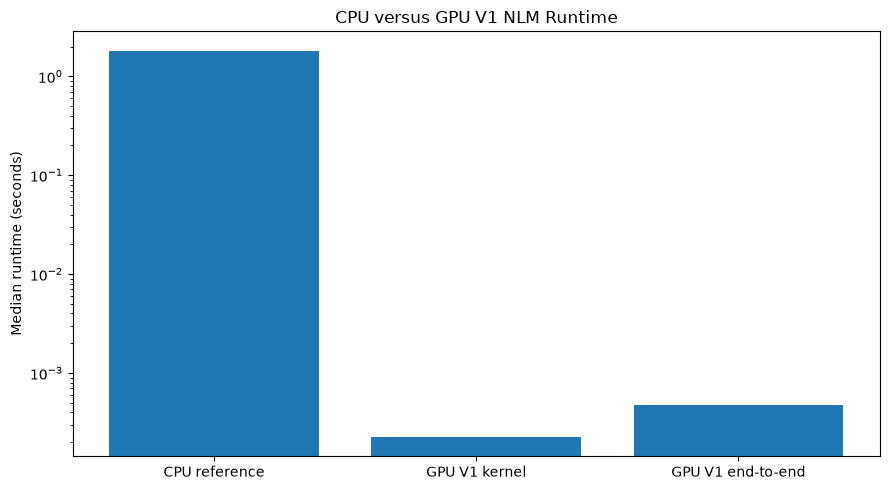

In [18]:
plt.figure(figsize=(9, 5))

plt.bar(
    [
        "CPU reference",
        "GPU V1 kernel",
        "GPU V1 end-to-end",
    ],
    [
        cpu_median_seconds,
        gpu_kernel_median_seconds,
        gpu_end_to_end_median_seconds,
    ],
)

plt.ylabel(
    "Median runtime (seconds)"
)

plt.title(
    "CPU versus GPU V1 NLM Runtime"
)

plt.yscale("log")
plt.tight_layout()
plt.show()

## GPU V1 Conclusion

GPU V1 successfully maps one CUDA thread to one output pixel.

The output is numerically consistent with the CPU reference within the
selected floating-point tolerance. PSNR and SSIM are also preserved.

GPU V1 substantially reduces both kernel-only and end-to-end runtime
compared with the naive Python CPU reference.

However, neighboring CUDA threads repeatedly load overlapping patch data
from global memory. GPU V2 will address this limitation using a
shared-memory tile and halo.